### Introduction
The purpose of the case study is to classify a given silhouette as one of four different types of vehicle, using a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.
Four &quot;Corgie&quot; model vehicles were used for the experiment: a double decker bus, Cheverolet
van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.
The purpose is to classify a given silhouette as one of three types of vehicle, using a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.
 
Link to the case file: vehicle.csvView in a new window

 
The points distribution for this case is as follows:<br>
1. Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)<br>
2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)<br>
3. Use PCA from scikit learn and elbow plot to find out reduced number of dimension (which covers more than 95% of the variance) - 10 points<br>
4. Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)<br>


### Question 1:
1. Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)

In [1]:
#For Numerial Operations numpy(Numerical Python) is used
import numpy as np

#For Data Analysis pandas(Python Data Analysis Library) is used
import pandas as pd

#For 2D graphs ploting matplotlib library is used
import matplotlib.pyplot as plt
#To enable matplotlib to plot in Jupyter Notebook
%matplotlib inline

#For better visualisation of Statistical Data seaborn library is used
import seaborn as sns

In [3]:
#Reading the data
data=pd.read_csv("vehicle.csv",sep=",")

In [4]:
data.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [4]:
data.shape

(846, 19)

In [6]:
data['class'].unique()

array(['van', 'car', 'bus'], dtype=object)

The dataset has 846-rows and 19-columns. The class variable has 3 unique values - Van Car and Bus

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

Only class atribute is of object type and all others are numeric.

Lets explore missing values

In [7]:
data.isna().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

There are NaN(Not a Number) entries as shown, which is same as null values output.

In [8]:
(data==0).sum()

compactness                     0
circularity                     0
distance_circularity            0
radius_ratio                    0
pr.axis_aspect_ratio            0
max.length_aspect_ratio         0
scatter_ratio                   0
elongatedness                   0
pr.axis_rectangularity          0
max.length_rectangularity       0
scaled_variance                 0
scaled_variance.1               0
scaled_radius_of_gyration       0
scaled_radius_of_gyration.1     0
skewness_about                 77
skewness_about.1               30
skewness_about.2                0
hollows_ratio                   0
class                           0
dtype: int64

There are zero values entred in column 'skewness_about' and 'skewness_about.1', which are not a missing values but the actual entries.

In [16]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.00,119.0
circularity,846.0,44.817967,6.135547,33.0,40.00,44.0,49.00,59.0
distance_circularity,846.0,82.171395,15.765746,40.0,70.00,80.0,98.00,112.0
radius_ratio,846.0,168.874704,33.401356,104.0,141.00,167.0,195.00,333.0
pr.axis_aspect_ratio,846.0,61.672577,7.883193,47.0,57.00,61.0,65.00,138.0
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.00,55.0
scatter_ratio,846.0,168.895981,33.195616,112.0,147.00,157.0,198.00,265.0
elongatedness,846.0,40.925532,7.815196,26.0,33.00,43.0,46.00,61.0
pr.axis_rectangularity,846.0,20.580378,2.588558,17.0,19.00,20.0,23.00,29.0
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.00,188.0


### Treating missing values and outliers

In [9]:
#Replacing all the null values with random inputs of their respective IQR[Inter Qurtile Range]
import random

In [10]:
data['circularity']=data['circularity'].fillna(random.randrange(40, 49))

data['distance_circularity']=data['distance_circularity'].fillna(random.randrange(70, 98))

data['radius_ratio']=data['radius_ratio'].fillna(random.randrange(141, 195))

data['pr.axis_aspect_ratio']=data['pr.axis_aspect_ratio'].fillna(random.randrange(57, 65))

data['scatter_ratio']=data['scatter_ratio'].fillna(random.randrange(147, 198))

data['elongatedness']=data['elongatedness'].fillna(random.randrange(33, 46))

data['pr.axis_rectangularity']=data['pr.axis_rectangularity'].fillna(random.randrange(19, 23))

data['scaled_variance']=data['scaled_variance'].fillna(random.randrange(167, 217))

data['scaled_variance.1']=data['scaled_variance.1'].fillna(random.randrange(318, 587))

data['scaled_radius_of_gyration']=data['scaled_radius_of_gyration'].fillna(random.randrange(149, 198))

data['scaled_radius_of_gyration.1']=data['scaled_radius_of_gyration.1'].fillna(random.randrange(67, 75))

data['skewness_about']=data['skewness_about'].fillna(random.randrange(2, 9))

data['skewness_about.1']=data['skewness_about.1'].fillna(random.randrange(5, 19))

data['skewness_about.2']=data['skewness_about.2'].fillna(random.randrange(184, 193))

In [11]:
data.isnull().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

All missing values are taken care of

#### Data Visualisation 

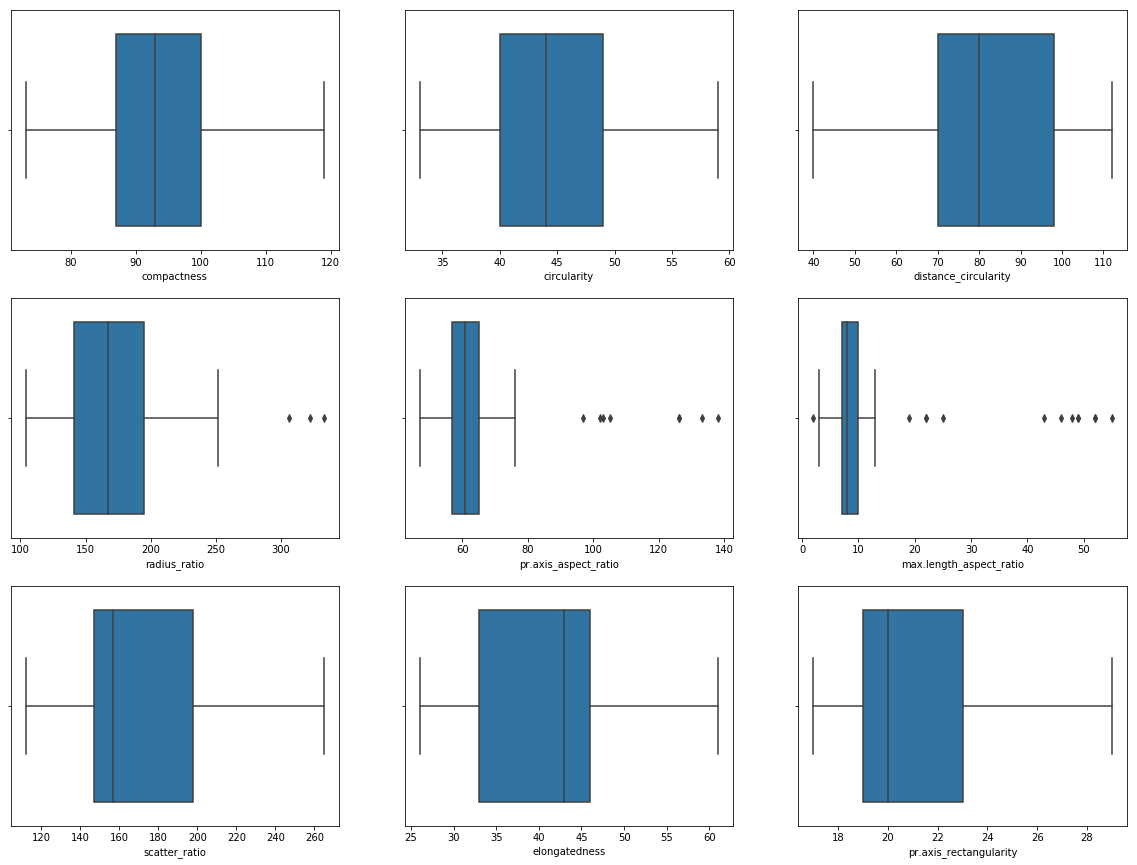

In [12]:
f,axes=plt.subplots(3,3,figsize=(20,15))
sns.boxplot(data['compactness'],ax=axes[0,0])
sns.boxplot(data['circularity'],ax=axes[0,1])
sns.boxplot(data['distance_circularity'],ax=axes[0,2])
sns.boxplot(data['radius_ratio'],ax=axes[1,0])
sns.boxplot(data['pr.axis_aspect_ratio'],ax=axes[1,1])
sns.boxplot(data['max.length_aspect_ratio'],ax=axes[1,2])
sns.boxplot(data['scatter_ratio'],ax=axes[2,0])
sns.boxplot(data['elongatedness'],ax=axes[2,1])
sns.boxplot(data['pr.axis_rectangularity'],ax=axes[2,2])
plt.show()

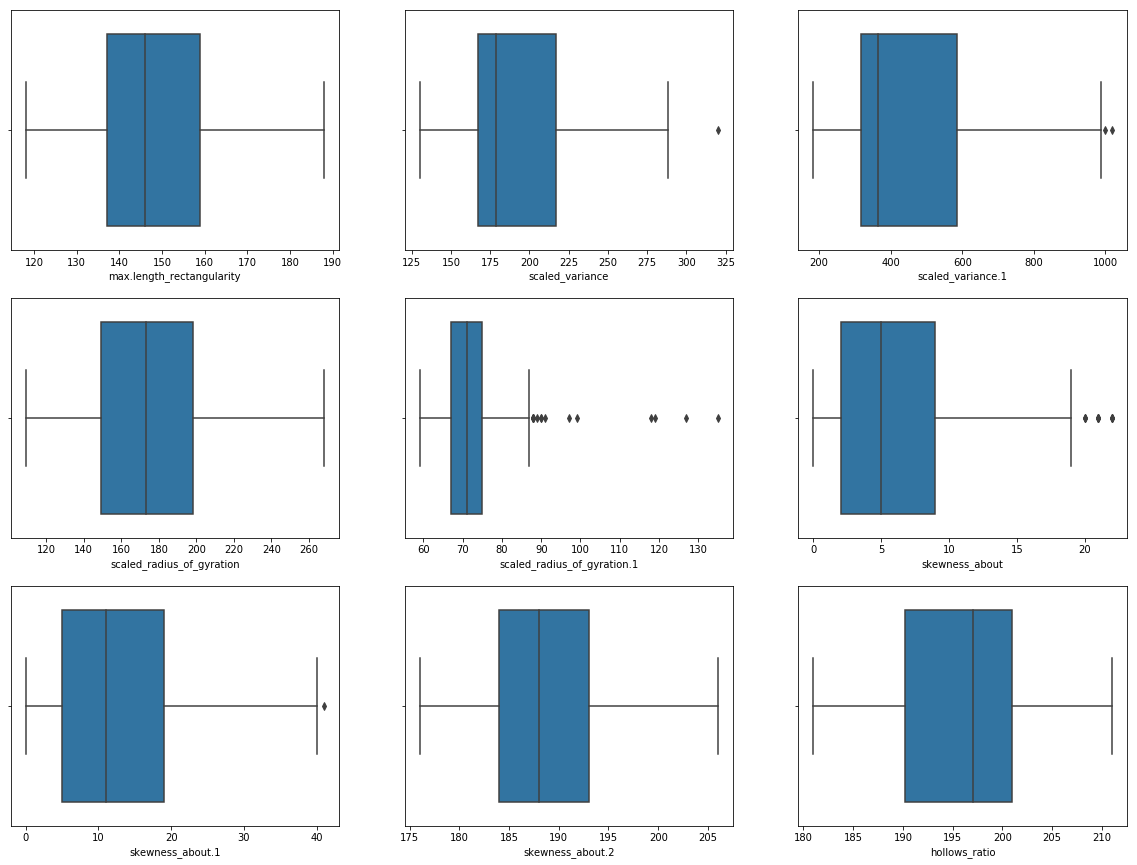

In [13]:
f,axes=plt.subplots(3,3,figsize=(20,15))
sns.boxplot(data['max.length_rectangularity'],ax=axes[0,0])
sns.boxplot(data['scaled_variance'],ax=axes[0,1])
sns.boxplot(data['scaled_variance.1'],ax=axes[0,2])
sns.boxplot(data['scaled_radius_of_gyration'],ax=axes[1,0])
sns.boxplot(data['scaled_radius_of_gyration.1'],ax=axes[1,1])
sns.boxplot(data['skewness_about'],ax=axes[1,2])
sns.boxplot(data['skewness_about.1'],ax=axes[2,0])
sns.boxplot(data['skewness_about.2'],ax=axes[2,1])
sns.boxplot(data['hollows_ratio'],ax=axes[2,2])
plt.show()

In [17]:
for i in range(len(data['radius_ratio'])):
    if data.loc[i,'radius_ratio']>300:
        data.loc[i,'radius_ratio']= random.randrange(141, 195)

In [18]:
for i in range(len(data['pr.axis_aspect_ratio'])):
    if data.loc[i,'pr.axis_aspect_ratio']>90:
        data.loc[i,'pr.axis_aspect_ratio']= random.randrange(57, 65)

In [19]:
for i in range(len(data['max.length_aspect_ratio'])):
    if data.loc[i,'max.length_aspect_ratio']>18:
        data.loc[i,'max.length_aspect_ratio']= random.randrange(7, 10)

In [20]:
for i in range(len(data['max.length_aspect_ratio'])):
    if data.loc[i,'max.length_aspect_ratio']<3:
        data.loc[i,'max.length_aspect_ratio']= random.randrange(7, 10)

In [21]:
for i in range(len(data['scaled_variance'])):
    if data.loc[i,'scaled_variance']>300:
        data.loc[i,'scaled_variance']= random.randrange(167, 217)

In [22]:
for i in range(len(data['scaled_variance.1'])):
    if data.loc[i,'scaled_variance.1']>982:
        data.loc[i,'scaled_variance.1']= random.randrange(318, 587)

In [23]:
for i in range(len(data['scaled_radius_of_gyration.1'])):
    if data.loc[i,'scaled_radius_of_gyration.1']>87:
        data.loc[i,'scaled_radius_of_gyration.1']= random.randrange(67, 75)

In [24]:
for i in range(len(data['skewness_about'])):
    if data.loc[i,'skewness_about']>18:
        data.loc[i,'skewness_about']= random.randrange(2, 9)

In [25]:
for i in range(len(data['skewness_about.1'])):
    if data.loc[i,'skewness_about.1']>39:
        data.loc[i,'skewness_about.1']= random.randrange(5, 19)

In [26]:
data_new=data.drop('class',axis=1)

In [27]:
from scipy.stats import zscore
data_new=data_new.apply(zscore)
data_new.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,0.160580,0.518929,0.052588,0.299402,1.932464,0.910948,-0.207861,0.137566,-0.224342,0.758332,-0.404441,-0.338535,0.287103,-0.311022,-0.007081,0.393942,-0.311590,0.183957
1,-0.325470,-0.622638,0.116055,-0.851652,-0.739465,0.426864,-0.599710,0.521660,-0.610886,-0.344578,-0.597768,-0.621442,-0.511774,0.013223,0.658563,0.167378,0.013648,0.452977
2,1.254193,0.845092,1.512310,1.263799,0.863692,0.910948,1.148542,-1.142750,0.935290,0.689401,1.109956,1.139512,1.393241,0.175345,1.767972,-0.399030,-0.148971,0.049447
3,-0.082445,-0.622638,-0.010878,-0.291680,0.329306,0.426864,-0.750422,0.649692,-0.610886,-0.344578,-0.919980,-0.742688,-1.464281,-1.445877,-0.007081,-0.285748,1.639837,1.529056
4,-1.054545,-0.133395,-0.772472,1.139361,0.507435,-0.541304,-0.599710,0.521660,-0.610886,-0.275646,1.689937,-0.650310,0.410008,0.013223,0.658563,-0.172467,-1.449922,-1.699181


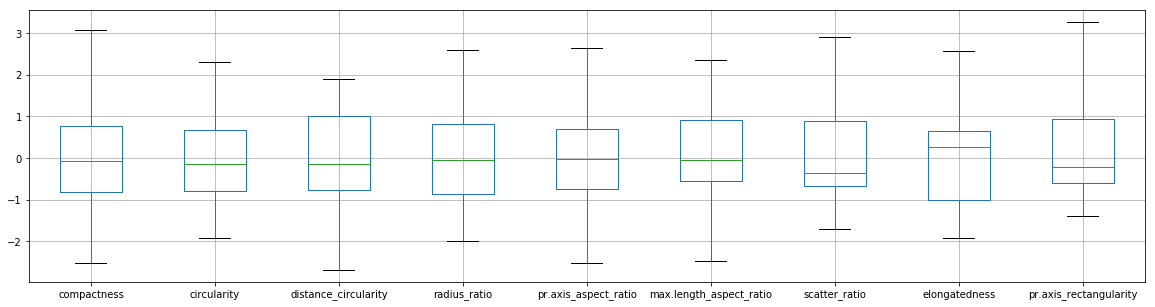

In [28]:
data_new.boxplot(column=['compactness','circularity','distance_circularity','radius_ratio','pr.axis_aspect_ratio','max.length_aspect_ratio','scatter_ratio','elongatedness','pr.axis_rectangularity'],figsize=(20,5))

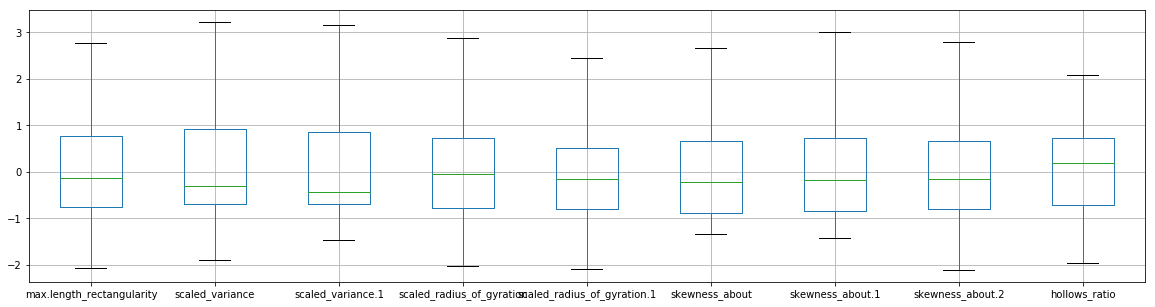

In [29]:
data_new.boxplot(column=['max.length_rectangularity','scaled_variance','scaled_variance.1','scaled_radius_of_gyration','scaled_radius_of_gyration.1','skewness_about','skewness_about.1','skewness_about.2','hollows_ratio'],figsize=(20,5))

From above we can see that the data is free from outliers and are on same scale.

### Question 2
Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)

Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

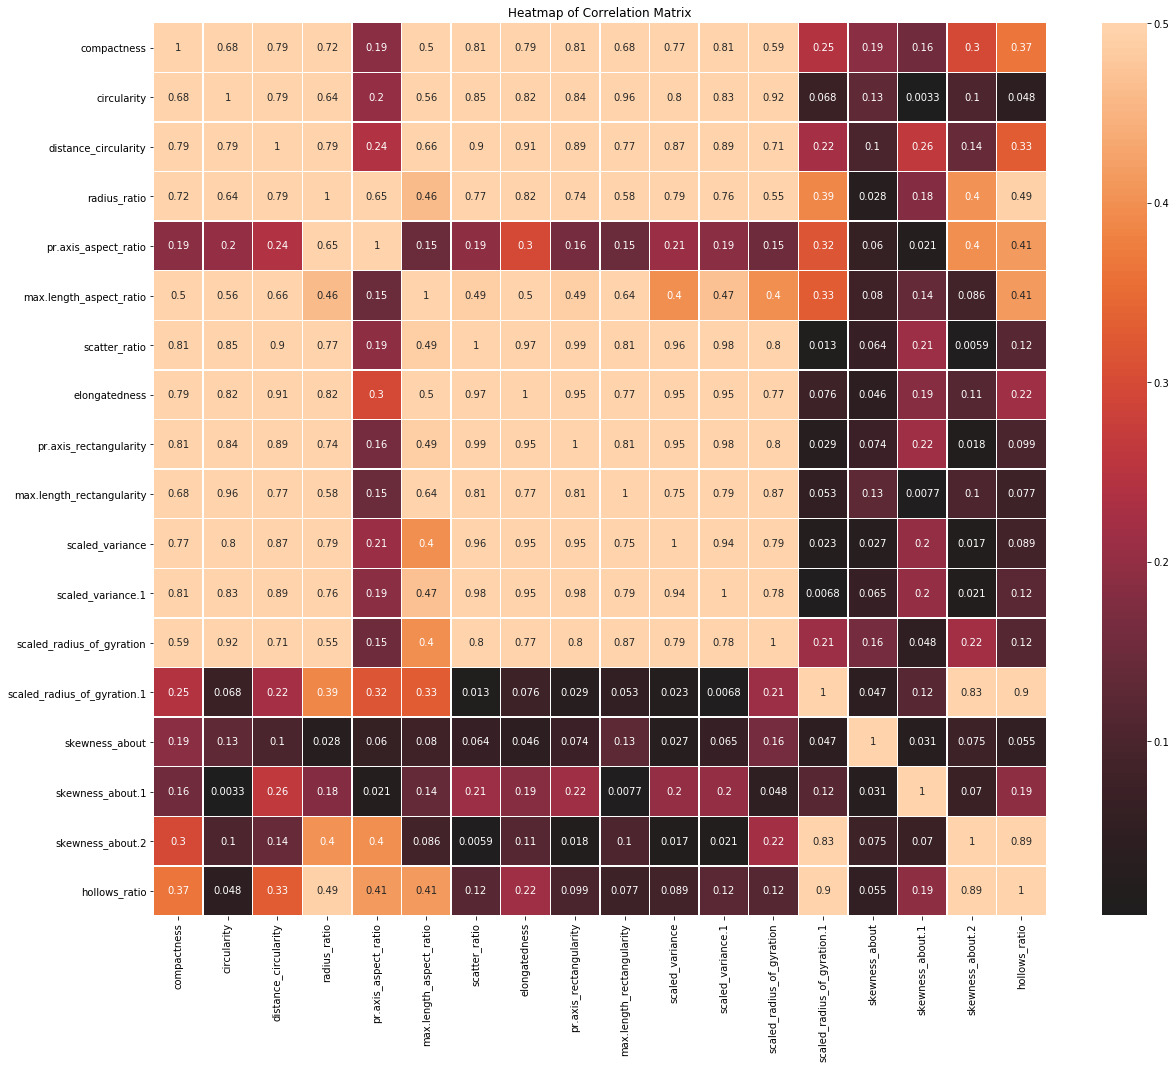

In [31]:
#Let us check for multi colkinierity among features
col_names =data_new.columns
corr_matrix = data_new[col_names].corr().abs()
plt.figure(figsize = (20,20))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(corr_matrix,annot=True, xticklabels=corr_matrix.columns.values, yticklabels=corr_matrix.columns.values, vmax=.5, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

The majority of the attributes are moderate-to-high in corelation with each other. Using PCA to remove multi colinierity 

Attributes with high correlation are as follows;

1. 'elongatedness' and 'scatter_ratio'

2. 'pr.axis_rectangularity' and 'scatter_ratio'

3. 'pr.axis_rectangularity' and 'elongatedness'

4. 'max.length_rectangularity' and 'circularity'
 
5. 'scaled_variance' and 'scatter_ratio'

6. 'scaled_variance' and 'elongatedness'

7. 'scaled_variance' and 'pr.axis_rectangularity'

8. 'scaled_variance.1' and 'scatter_ratio'

9. 'scaled_variance.1' and 'elongatedness'

10. 'scaled_variance.1' and 'pr.axis_rectangularity'

We have 10 combinations of 7 attributes which are highly co-related (more than 90%).

In [32]:
# Step 1 - Create covariance matrix

cov_matrix = np.cov(data_new.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00118343  0.68495495  0.78927864  0.72161706  0.19145201  0.50093953
   0.81337014 -0.78873887  0.81465658  0.67694334  0.77217246  0.81169603
   0.58715347 -0.24535511  0.18951721  0.15580042  0.29888625  0.36598446]
 [ 0.68495495  1.00118343  0.79177152  0.63946772  0.2032874   0.56048142
   0.84728092 -0.8198478   0.84302175  0.961564    0.80064987  0.83019868
   0.92552256  0.06762891  0.13146026 -0.0032694  -0.1027511   0.04764626]
 [ 0.78927864  0.79177152  1.00118343  0.79168171  0.24162311  0.66488343
   0.9043673  -0.91075026  0.89300635  0.77503171  0.86967267  0.88703477
   0.70674239 -0.22334632  0.1020297   0.26460332  0.14322299  0.3279889 ]
 [ 0.72161706  0.63946772  0.79168171  1.00118343  0.64908328  0.46261479
   0.76967199 -0.82520034  0.74417521  0.5811169   0.78989648  0.75955464
   0.55370958 -0.38917159  0.02828736  0.18028973  0.40525732  0.49175527]
 [ 0.19145201  0.2032874   0.24162311  0.64908328  1.00118343  0.14866835
   0.1930963

In [33]:
# Step 2- Get eigen values and eigen vector
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-2.72592423e-01 -8.69152704e-02  3.34346425e-02  1.36902952e-01
  -1.25267418e-01  2.71931313e-01  1.94246822e-01 -7.52015527e-01
   3.79623510e-01  1.67576888e-01  8.26838997e-02  1.32269281e-02
   1.59000786e-02  6.52349287e-02 -5.88483009e-02 -1.09715415e-01
   4.27843443e-02  6.58328366e-02]
 [-2.87017097e-01  1.30617325e-01  2.03137237e-01 -3.77535922e-02
   1.35945353e-01 -7.84168324e-02 -3.95527056e-01 -6.76207779e-02
   4.92568737e-02 -1.86931071e-01  7.60763566e-03  1.45327534e-01
   4.87805925e-02  5.40396569e-02 -4.20376945e-01  5.07711286e-02
  -6.38149514e-01  1.47814478e-01]
 [-3.02048081e-01 -4.39712673e-02 -6.33578912e-02  1.09632256e-01
   7.72710097e-02 -2.25923681e-02  1.68278645e-01  2.78565112e-01
   5.31724612e-02  3.04634676e-01  5.19228135e-01  6.08115058e-01
  -7.76903668e-03 -1.51753445e-01  4.56732719e-02  1.32313916e-01
   6.25391843e-03 -2.54874059e-02]
 [-2.69534446e-01 -1.98489300e-01 -5.48553606e-02 -2.52205114e-01
  -1.39193949e-01 -

In [34]:
#Step 3- Find variance and cumulative variance by each eigen vector

tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 54.0858577   72.59706147  79.13180749  85.44825133  90.36470617
  94.10811963  95.8935837   97.16769711  97.92643515  98.37601271
  98.7940828   99.16564608  99.38843836  99.5688554   99.73599098
  99.85652925  99.96808163 100.        ]


The Eigen values are sorted from highest to lowest variance.

As per the requirement to cover 95% variation, 7 PC dimensions are good

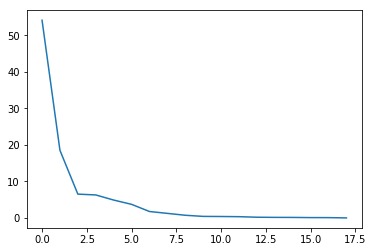

In [35]:
plt.plot(var_exp)

Visually we can observe that their is steep drop in variance explained with increase in number of PC dimensions.


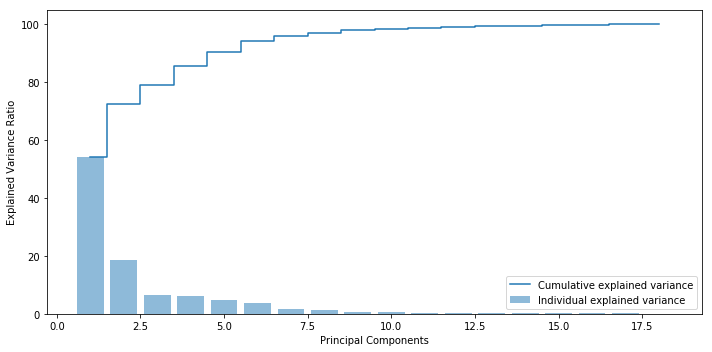

In [36]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [55]:
from sklearn.decomposition import PCA

# NOTE - we shall generate PC dimensions for raw data (7 dimensions to captured 95% variance)

pca = PCA(n_components=7)
data_pca = pca.fit_transform(data_new)
#pca.fit_transform(data_new).transpose()

In [56]:
pca.components_

array([[ 2.72592423e-01,  2.87017097e-01,  3.02048081e-01,
         2.69534446e-01,  9.72579087e-02,  1.94982576e-01,
         3.10449688e-01, -3.08784950e-01,  3.07332786e-01,
         2.78222498e-01,  2.99940433e-01,  3.06310616e-01,
         2.63520904e-01, -4.14804911e-02,  3.52509024e-02,
         5.95696641e-02,  3.80565493e-02,  8.46948006e-02],
       [-8.69152704e-02,  1.30617325e-01, -4.39712673e-02,
        -1.98489300e-01, -2.59075849e-01, -1.08125295e-01,
         7.55380131e-02, -1.32630244e-02,  8.79484919e-02,
         1.22041753e-01,  7.53225139e-02,  7.09704636e-02,
         2.08952051e-01,  5.03331867e-01, -9.16838232e-03,
        -8.83597523e-02, -5.02474299e-01, -5.08571364e-01],
       [-3.34346425e-02, -2.03137237e-01,  6.33578912e-02,
         5.48553606e-02, -7.18109125e-02, -1.54770753e-01,
         1.10560811e-01, -9.20272098e-02,  1.06560728e-01,
        -2.17243817e-01,  1.46146446e-01,  1.07010108e-01,
        -2.04016681e-01,  7.31857142e-02, -5.38251096e

In [57]:
data_pca.shape

(846, 7)

In [58]:
#Converting to dataframe
data_comp_full = pd.DataFrame(data_pca,columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7'])

#reinserting the droped target variable
data_comp_full['class'] = data['class']
data_comp_full.head(20)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,class
0,0.580387,-0.674554,-0.487907,-0.719633,-0.691679,-1.887527,-0.174411,van
1,-1.514478,-0.339141,-0.328488,1.294941,-0.308624,-0.135690,0.210472,van
2,3.911078,0.242685,-1.274253,0.208836,0.989030,-0.676465,0.814052,car
3,-1.539712,-3.040361,-0.487337,0.356284,-0.590083,0.331308,0.127049,van
4,-0.690833,1.444895,-0.213315,-0.987923,0.931506,-1.196688,0.300619,bus
5,5.343221,4.631690,1.211366,0.209083,1.517493,2.579252,0.428680,bus
6,-0.818089,-2.216111,-1.970066,-0.317714,1.578478,0.665339,-0.401024,bus
7,-1.962438,-1.563648,-1.056169,-0.884317,-1.170818,0.012563,-0.325741,van
8,-4.382564,-3.289766,0.560378,0.057490,-0.455103,0.641915,-0.344642,van
9,1.220832,-1.975582,0.459802,0.492198,-1.035635,0.338267,0.698550,car


In [37]:
#Let us check it visually
#sns.pairplot(data_comp_full, diag_kind='kde') 

Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

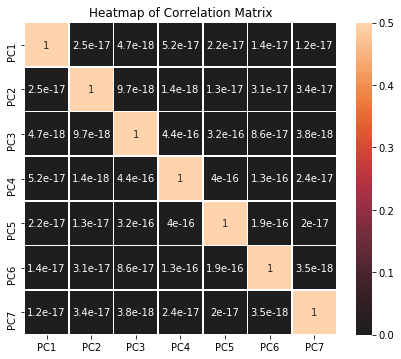

In [61]:
#Now let us check again to see if PCA has removed multi colkinierity among new PC dimensions
col_names =data_comp_full.columns
corr_matrix = data_comp_full[col_names].corr().abs()
plt.figure(figsize = (7,7))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(corr_matrix,annot=True, xticklabels=corr_matrix.columns.values, yticklabels=corr_matrix.columns.values, vmax=.5, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

### Now multi colinierity is removed and dimensions are also reduced. These 7 PC features capture 95% of the variance

### Question 4:
Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)

In [62]:
from sklearn.model_selection import train_test_split

# To calculate the accuracy score of the model
from sklearn.metrics import accuracy_score

target = data_comp_full["class"]
features = data_comp_full.drop("class", axis=1)
X_train, X_test, y_train, y_test = train_test_split(features,target, test_size = 0.30, random_state = 7)

The dataset is split into Test an Train in the ratio 70:30.

In [70]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Using Grid Search with C values - 0.01, 0.05, 0.5 and 1 and with Kernal - Linear and RBF and Cross Validation with 5 folds

In [75]:
params = {'C': [0.01, 0.05, 0.5, 1], 
          'kernel': ['linear','rbf']}
model = SVC()
#Making models with hyper parameters sets
model1 = GridSearchCV(model, param_grid=params, cv=5,n_jobs=-1)
#Learning
model1.fit(X_train,y_train)
#The best hyper parameters set
print("Best Hyper Parameters:\n",model1.best_params_)
#Prediction
prediction=model1.predict(X_test)
#importing the metrics module
from sklearn import metrics
#evaluation(Accuracy)
print("Accuracy:",metrics.accuracy_score(prediction,y_test))
#evaluation(Confusion Metrix)
print("Confusion Matrix:\n",metrics.confusion_matrix(prediction,y_test))

Best Hyper Parameters:
 {'C': 1, 'kernel': 'rbf'}
Accuracy: 0.9330708661417323
Confusion Matrix:
 [[ 66   3   1]
 [  0 115   4]
 [  0   9  56]]


/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)
/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
